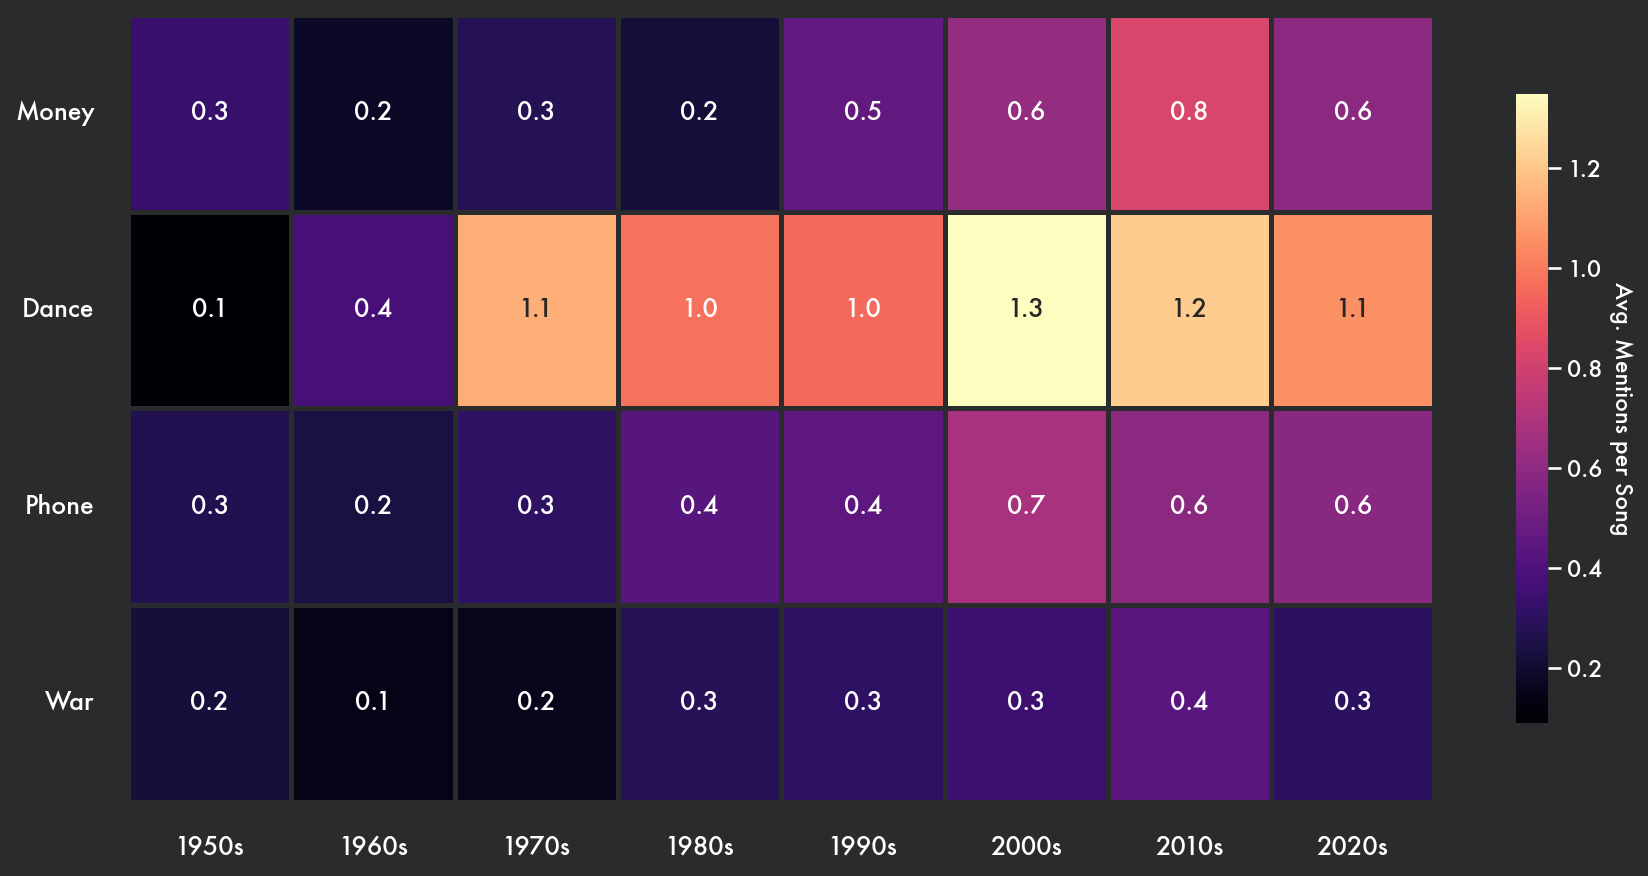

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.font_manager as fm
import re
import json

with open('config.json', 'r') as f:
    config = json.load(f)

# Load colors from config
BG_COLOR = config["colors"]["BG_COLOR"]
TITLE_COLOR = config["colors"]["TITLE_COLOR"]
TEXT_COLOR = config["colors"]["TEXT_COLOR"]
US_COLOR = config["colors"]["US_COLOR"]
CH_COLOR = config["colors"]["CH_COLOR"]
GRID_COLOR = config["colors"]["GRID_COLOR"]
ACCENT_COLOR = config["colors"]["ACCENT_COLOR"]

# Load fonts from config
font_path_title = "style/" + config["fonts"]["title_font_path"]
font_path_main = "style/" + config["fonts"]["main_font_path"]

fm.fontManager.addfont(font_path_title)
fm.fontManager.addfont(font_path_main)

title_font_name = fm.FontProperties(fname=font_path_title).get_name()
main_font_name = fm.FontProperties(fname=font_path_main).get_name()

# Define cultural markers and similar words
CULTURAL_MARKERS = {
    "Money": ["money", "cash", "bills", "dollar", "dollars", "bands", "wealth", "rich", "bling", "pay", "paid"],
    "Dance": ["dance", "dancing", "groove", "boogie", "club", "party", "disco", "rhythm", "beat"],
    "Phone": ["phone", "call", "telephone", "mobile", "text", "ring", "dial", "cell", "cellphone"],
    "War":   ["war", "fight", "battle", "soldier", "army", "gun", "guns", "weapon", "shoot", "combat"]
}

def count_marker_mentions(text, keywords):
    """Counts the total occurrences of keywords in a text."""

    if pd.isna(text) or not isinstance(text, str):
        return 0
    
    # Create a regex pattern that looks for the words
    pattern = r'\b(?:' + '|'.join(keywords) + r')\b'
    
    matches = re.findall(pattern, str(text), flags=re.I)
    return len(matches)

def prepare_heatmap_data(df_usa: pd.DataFrame, df_ch: pd.DataFrame):
    """Combines datasets, extracts decade, and calculates the average mentions per song for each category."""
    
    # Combine USA and Switzerland data
    df = pd.concat([df_usa, df_ch], ignore_index=True)

    df['Decade'] = (df['Year'] // 10) * 10
    
    # Count occurrences for each category
    for category, keywords in CULTURAL_MARKERS.items():
        df[category] = df['Lyrics'].apply(lambda x: count_marker_mentions(x, keywords))
    
    # Calculate the average mentions per song for each decade
    yearly_avg = df.groupby('Decade')[list(CULTURAL_MARKERS.keys())].mean()
    
    # Transpose the data so categories are rows and decades are columns
    heatmap_data = yearly_avg.T
    
    # Ensure columns are integers
    heatmap_data.columns = [f"{int(col)}s" for col in heatmap_data.columns]
    
    return heatmap_data

def format_heatmap_aesthetics(ax: plt.Axes, cbar_ax):
    """Applies styling and fonts to the heatmap."""
    
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Format tick parameters
    ax.tick_params(axis='x', colors=TEXT_COLOR, labelsize=12, labelrotation=0, pad=10)
    ax.tick_params(axis='y', colors=TEXT_COLOR, labelsize=12, labelrotation=0, pad=10)

    # Format the colorbar
    if cbar_ax:
        cbar_ax.tick_params(colors=TEXT_COLOR)
        cbar_ax.set_ylabel('Avg. Mentions per Song', color=TEXT_COLOR, fontsize=11, labelpad=15, rotation=270)
        cbar_ax.spines['outline'].set_visible(False)

def create_cultural_marker_heatmap(df_usa: pd.DataFrame, df_ch: pd.DataFrame):
    # Get prepped data
    heatmap_data = prepare_heatmap_data(df_usa, df_ch)

    # Canvas setup
    sns.set_theme(style="whitegrid", rc={
        "axes.facecolor": BG_COLOR, 
        "figure.facecolor": BG_COLOR,
        "font.family": main_font_name  
    })
    
    fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

    # Plotting the heatmap
    sns.heatmap(
        heatmap_data, 
        ax=ax, 
        cmap="magma",
        annot=True,
        fmt=".1f",
        linewidths=1.5,
        linecolor=BG_COLOR,
        cbar_kws={"shrink": 0.8}
    )

    # Apply styling
    format_heatmap_aesthetics(ax, ax.collections[0].colorbar.ax)

    plt.tight_layout()
    return fig

if __name__ == "__main__":
    # Load datasets
    df_usa = pd.read_csv('data/US/songs_analyzed.csv')
    df_ch = pd.read_csv('data/CH/songs_analyzed.csv') 

    # Fenerate and show plot
    heatmap_fig = create_cultural_marker_heatmap(df_usa, df_ch)
    plt.show()

    # Save the chart
    heatmap_fig.savefig('chartsPNG/chart4.png', dpi=300, bbox_inches='tight')